In [1]:
%cd ../.
import os, sys
sys.path.insert(0, os.path.abspath('../Scripts'))
sys.path.insert(0, os.path.expanduser('~/CDD_Vault_API/python'))  # CDD Vault API (get_df)

/home/gtamo/ADME_ML


In [2]:
%load_ext autoreload
%autoreload 2

import re
import os
import pandas as pd
import numpy as np
# import py3Dmol
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.patches import FancyBboxPatch
from PIL import Image
import io
from matplotlib.colors import LinearSegmentedColormap
import csv
import pickle
import json

from pathlib import Path
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem,rdFMCS
# import prolif as plf
from glob import glob
# import meeko
import subprocess as sub
# from vina import Vina
import time
from tqdm import tqdm
tqdm.pandas()
import importlib
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, HistGradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import StratifiedKFold, cross_val_predict, KFold, StratifiedGroupKFold
from sklearn import metrics as _m
from sklearn.metrics import f1_score, silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import roc_auc_score, average_precision_score, matthews_corrcoef
# from xgboost import XGBClassifier,XGBRegressor
from openTSNE import TSNE as oTSNE        # pip install openTSNE
import seaborn as sns
from rdkit.Chem import Draw   # CAUTION: must come AFTER seaborn — the reverse order segfaults the kernel
from scipy import stats
import csv, contextlib, threading, joblib
import joblib
from joblib import Parallel, delayed
from datetime import date
## load internal (in-house) + public-augmented data, champion model, eval helpers
from copy import deepcopy
from itertools import combinations


# user defined modules
import Rdkit_tools as rdkit_tools
importlib.reload(rdkit_tools)
import Molecule as M
import ML_Reg as ML_Reg
import ML_Class as ML_Class
# from MolViz3D import MolViz3D
import Statistics_tools as stats_tools
import python.functions as fn
importlib.reload(fn)                  # %autoreload misses a NEWLY ADDED module-level name
from python.harmonize_sol import harmonize_solubility

from get_library import get_df   # CDD Vault collection export
from get_protocol_data import get_data, load_config, alias_map
# from tdc.multi_pred import DTI

import yaml
from python.ADME_build_ML import PARAMS, DATA, OUTPUT   # CLI classes reused here (%autoreload picks up edits)
from IPython.display import HTML, SVG, display

In [3]:
## 1. import datasets
## params — every YAML key becomes an attribute (params.ADME_CACHE); see python/ADME_build_ML.py:PARAMS
params = PARAMS('config/config.yaml')
params.load_params()

## public logD 7.4 = TDC Lipophilicity_AstraZeneca, already harmonized into the ADME cache.
## Take the 4 meta columns only — the parquet also holds pre-built HASHED H237 features, and this
## notebook builds its own UNHASHED Morgan bits, which are the ones you can map back to atoms.
logd = pd.read_parquet(os.path.join(params.ADME_CACHE, params.ENDPOINT_PUBLIC_FILES['logd'][0]),
                       columns=['compound', 'smiles', 'value', 'origin'])
print(f'> logD: {len(logd)} rows | {logd.compound.nunique()} compounds | source(s) {list(logd.origin.unique())}')
print(f'> logD 7.4: {logd.value.min():.2f} to {logd.value.max():.2f} '
      f'(mean {logd.value.mean():.2f}, sd {logd.value.std():.2f}) | {logd.value.isna().sum()} nulls')

## every SMILES must parse, or the fingerprint step below silently drops rows
logd['mol'] = logd['smiles'].progress_apply(Chem.MolFromSmiles)
print(f'> unparseable SMILES: {int(logd.mol.isna().sum())}')

> loaded 17 params from config/config.yaml
> logD: 4200 rows | 4200 compounds | source(s) ['TDC:Lipophilicity_AstraZeneca']
> logD 7.4: -1.50 to 4.50 (mean 2.19, sd 1.20) | 0 nulls


100%|██████████| 4200/4200 [00:00<00:00, 8421.85it/s]

> unparseable SMILES: 0


In [4]:
## 2. Build unhashed morgan fingerprints:
## every column IS one atom environment — no hash collisions, so a tree split maps to a substructure.
## Column names keep RDKit's raw bit id (B<id>), which is stable across datasets; never renumber them.
MF_RADIUS   = 2                        # RDKit emits environments at radius 0, 1 and 2
MF_MIN_CPDS = 2                        # a bit in one compound only cannot inform a split
X_logd, bits_logd = rdkit_tools.unhashed_morgan(logd, radius=MF_RADIUS,
                                                min_compounds=MF_MIN_CPDS,
                                                return_bits=True, v=True)

## the bit index explains every column: its radius, how many compounds carry it, and — for a bit
## absorbed by an identical column — which column took it over
print(bits_logd[bits_logd.kept].radius.value_counts().sort_index().rename('kept bits').to_frame().T.to_string())
print(f'> absorbed as duplicate: {int(bits_logd.duplicate_of.notna().sum())} | '
      f'dropped as rare: {int(((~bits_logd.kept) & bits_logd.duplicate_of.isna()).sum())}')

## ML frame: one row per compound, the logD label alongside its bits
ML_logd = X_logd.merge(logd[['compound', 'value']], on='compound').rename(columns={'value': 'label'})
print(f'> ML frame: {ML_logd.shape[0]} compounds x {ML_logd.shape[1] - 2} bits')

unhashed Morgan: 100%|██████████| 4200/4200 [00:01<00:00, 4115.49it/s]


> unhashed Morgan r=2: 4200 compounds x 5957 bits (15872 found, 9915 dropped as rare or duplicate) | 0 all-zero rows
radius      0     1     2
kept bits  45  1233  4679
> absorbed as duplicate: 1999 | dropped as rare: 7916
> ML frame: 4200 compounds x 5957 bits


> logD > 3: high 1163 | low 3037 (27.7% high)
> dimension dataset: (4200, 5959)


  0%|          | 0/5 [00:00<?, ?it/s]

>> fold 1 - dim train: (3359, 5957) - test: (841, 5957)


 20%|██        | 1/5 [00:00<00:01,  3.71it/s]

-----------------------------------------
> Fold 1 Accuracy: 0.73, F1: 0.41, Roc_auc: 0.73, PR_auc: 0.54
>> True negative (False negative):  531 ( 152 )
>> True positive (False positive):  81 ( 77 )
>> fold 2 - dim train: (3360, 5957) - test: (840, 5957)


...

-----------------------------------------
> Fold 3 Accuracy: 0.74, F1: 0.43, Roc_auc: 0.75, PR_auc: 0.54
>> True negative (False negative):  537 ( 151 )
>> True positive (False positive):  82 ( 70 )
>> fold 4 - dim train: (3360, 5957) - test: (840, 5957)


 80%|████████  | 4/5 [00:01<00:00,  3.70it/s]

-----------------------------------------
> Fold 4 Accuracy: 0.73, F1: 0.52, Roc_auc: 0.71, PR_auc: 0.53
>> True negative (False negative):  493 ( 110 )
>> True positive (False positive):  123 ( 114 )
>> fold 5 - dim train: (3361, 5957) - test: (839, 5957)


100%|██████████| 5/5 [00:01<00:00,  3.69it/s]

-----------------------------------------
> Fold 5 Accuracy: 0.74, F1: 0.43, Roc_auc: 0.73, PR_auc: 0.54
>> True negative (False negative):  540 ( 149 )
>> True positive (False positive):  83 ( 67 )

>>> Global accuracy: 0.73, F1: 0.48, ROC_AUC: 0.73, PR_AUC: 0.54


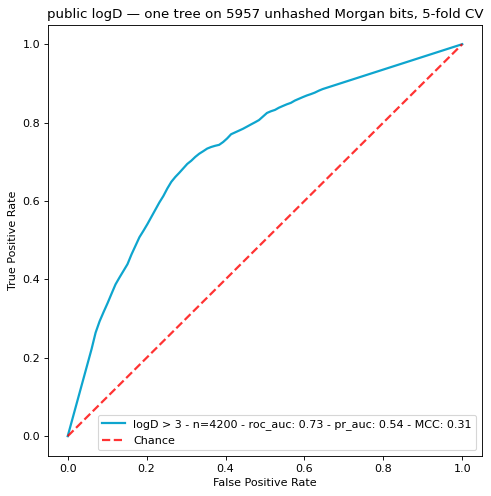

predicted     0    1
actual              
0          2571  466
1           649  514


In [5]:
## 3. Classification:
## binarize logD at the medchem lipophilicity line; 2.36 (the median) is the balanced alternative
LOGD_HI = 3.0                          # logD 7.4 above this counts as too lipophilic
ML_logd_clf = ML_logd.assign(label=(ML_logd['label'] > LOGD_HI).astype(int))
print(f'> logD > {LOGD_HI:g}: high {int(ML_logd_clf.label.sum())} | '
      f'low {int((1 - ML_logd_clf.label).sum())} ({ML_logd_clf.label.mean():.1%} high)')

## folds grouped by skeleton InChIKey so salts/stereoisomers/tautomers never split, and stratified
## on the class to hold the ratio — same scheme as FP_preds (config FOLD_GROUP_BY_INCHIKEY)
_grp = fn.inchikeys_for(logd, level='skeleton')
_ids = ML_logd_clf['compound'].to_numpy()
folds_logd = [[list(_ids[tr]), list(_ids[te])] for tr, te in
              StratifiedGroupKFold(n_splits=params.RF_SINGLETASK['cv_folds'], shuffle=True,
                                   random_state=params.RF_SINGLETASK['seed']
                                   ).split(_ids, ML_logd_clf['label'], _grp)]

## the SAME single decision tree as FP_preds: champion knobs minus the RF-only n_estimators/n_jobs
TREE_KW = {k: v for k, v in params.RF_SINGLETASK['champion'].items() if k != 'n_estimators'}
clf_logd, pred_logd = ML_Class.K_fold_by_defined_IDs_Classification(
    ML_logd_clf, ID='compound', ID_sets=folds_logd,
    model=DecisionTreeClassifier(**TREE_KW, random_state=params.RF_SINGLETASK['seed']),
    col_to_rm=['compound', 'label'], v=True)

## ROC curve — CAUTION: one tree emits only a handful of distinct probabilities, so the curve
## is a coarse staircase and its ROC-AUC understates the model against a forest
roc_logd = ML_Class.plot_roc_curve([pred_logd], c=[params.SERAC_C['azure']],
                                   l=[f'logD > {LOGD_HI:g}'],
                                   metric2show=['roc_auc', 'pr_auc', 'MCC'])
plt.title(f"public logD — one tree on {ML_logd_clf.shape[1] - 2} unhashed Morgan bits, "
          f"{params.RF_SINGLETASK['cv_folds']}-fold CV")
plt.show()

print(pd.crosstab(pred_logd['real_y'], pred_logd['pred_y'], rownames=['actual'], colnames=['predicted']))

> tree: 15 nodes | 8 leaves


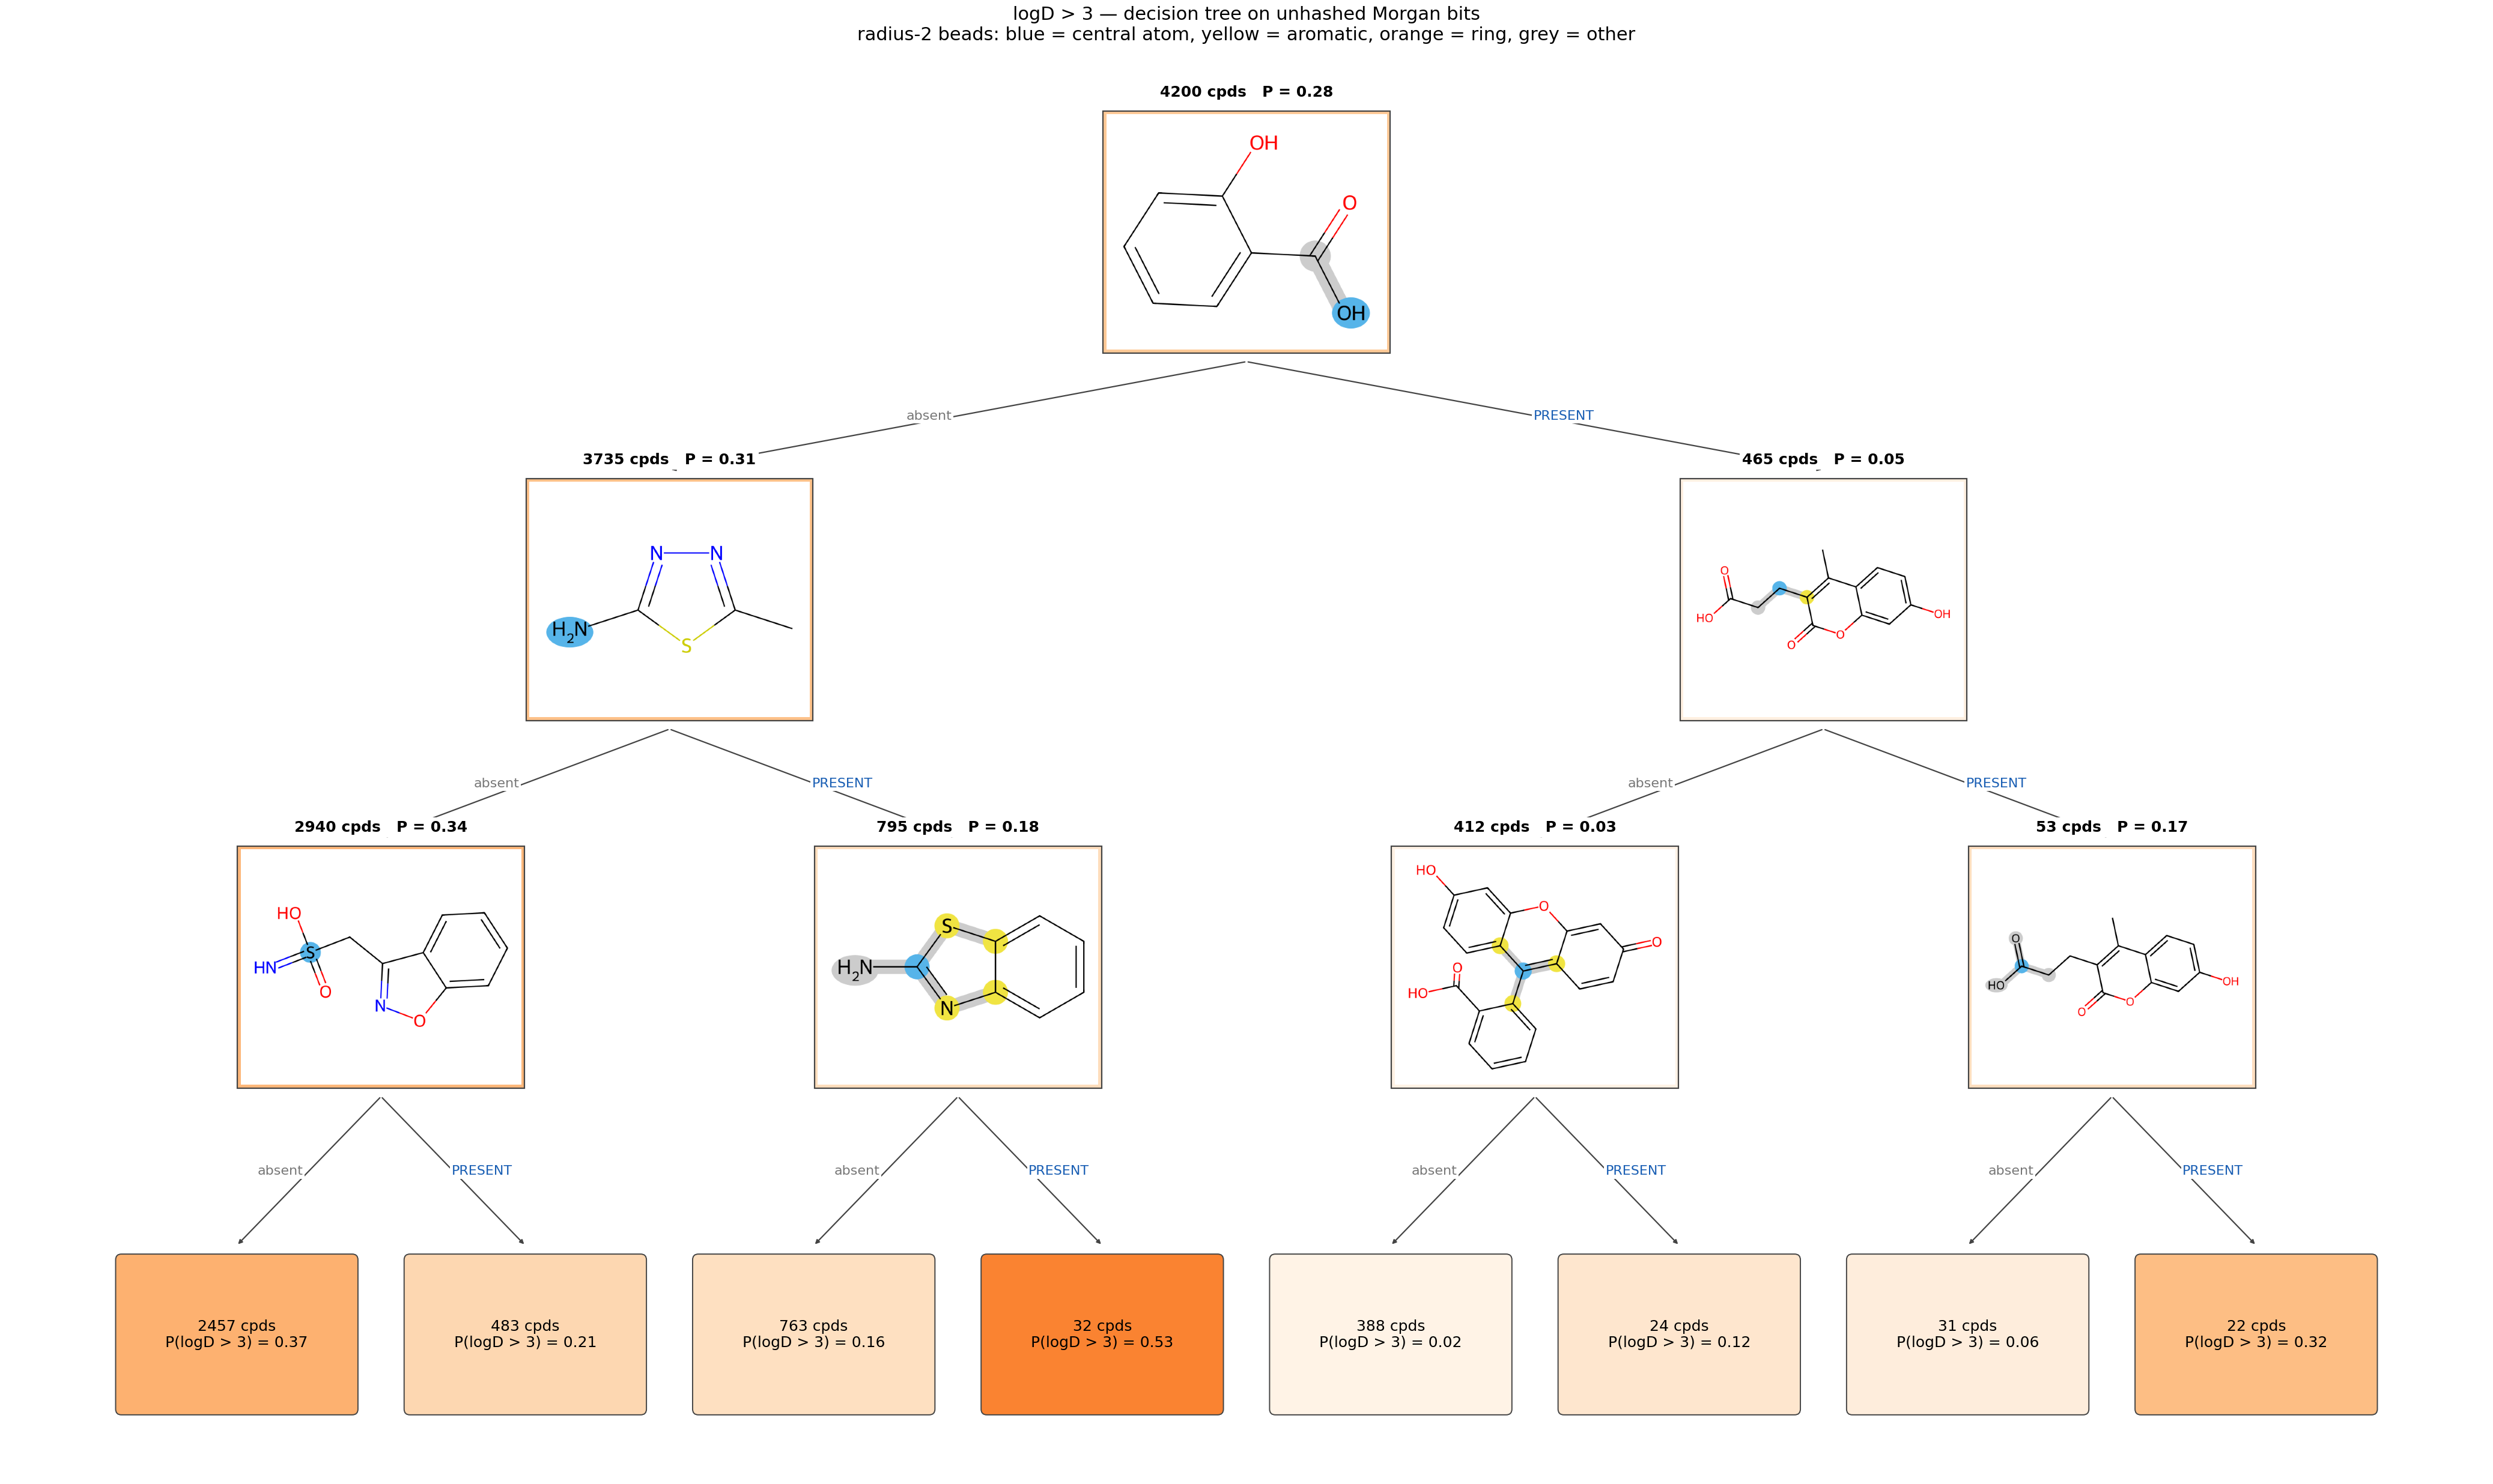

In [9]:
## 4. Draw the tree: every split box holds its bit, drawn on a molecule that carries it
FEAT_logd = [c for c in ML_logd_clf.columns if c not in ('compound', 'label')]

VIZ_DEPTH = 3                          # 8 leaves still fits one readable figure; 4 gets cramped
tree_viz = DecisionTreeClassifier(max_depth=VIZ_DEPTH, min_samples_leaf=20,
                                  random_state=params.RF_SINGLETASK['seed']
                                  ).fit(ML_logd_clf[FEAT_logd], ML_logd_clf['label'])

## the tree alone cannot do it: feature NAMES come from ML_df, and the structures from mols
fig = rdkit_tools.plot_decision_tree_MF_bits(tree_viz, ML_logd_clf, dict(zip(logd.compound, logd.mol)),
                                    radius=MF_RADIUS, pos_label=f'logD > {LOGD_HI:g}')
plt.show()